In [36]:
# === Imports ===
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [37]:
# === Reproducibility ===
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [38]:
# Required access method:
dataX = np.load('version4ftrDataX.npy')
dataY = np.load('version4ftrDataY.npy')
blobPerFrame = np.load('version4ftrblobsPerFrame.npy')

indRange = np.arange(len(blobPerFrame))

x = dataX  # pandas DataFrame of shape (20640, 8)
y = dataY  # pandas Series

print("X shape:", x.shape)
print("y shape:", y.shape)
print("Blob Per frame :", blobPerFrame)


BATCH_SIZE=64
EPOCHS=12


X shape: (6557, 5)
y shape: (6557,)
Blob Per frame : [32 31 29 39 48 46 43 43 49 56 48 57 68 59 59 71 64 75 75 69 69 66 76 79
 65 72 64 74 68 74 77 73 79 77 78 67 76 77 80 75 61 74 67 76 74 56 71 83
 71 66 76 76 73 66 66 79 86 73 79 81 80 78 84 77 69 76 88 75 91 77 71 83
 74 85 89 79 71 79 88 79 69 81 76 71 74 73 75 63 74 60 52 36 25 20 19 20
 23 27 22 23]


In [39]:
## Data split
split_indices = np.cumsum(blobPerFrame)[:-1]
framesX = np.split(x, split_indices)
framesY = np.split(y, split_indices)

X_train_frame, X_temp_frame, y_train_frame, y_temp_frame = train_test_split(
    framesX, framesY,
    test_size=0.4,
    random_state= SEED
)

X_val_frame, X_test_frame, y_val_frame, y_test_frame = train_test_split(
    X_temp_frame, y_temp_frame,
    test_size= 0.5,
    random_state=SEED
)

train_blobsX = np.concatenate(X_train_frame)
val_blobsX = np.concatenate(X_val_frame)
test_blobsX = np.concatenate(X_test_frame)

train_blobsY = np.concatenate(y_train_frame)
val_blobsY = np.concatenate(y_val_frame)
test_blobsY = np.concatenate(y_test_frame)

print("Train:", train_blobsX.shape,"Val:", val_blobsX.shape, "Test:", test_blobsX.shape)

inputVariables = [
    "radius", "theta (radians)", "dot_productNorm", "area", "solidity",
]

Train: (3926, 5) Val: (1354, 5) Test: (1277, 5)


In [40]:
### Preprocessing

# Standardize features using statistics from the training set only.

scaler = StandardScaler()

X_train_s = scaler.fit_transform(train_blobsX)
X_val_s   = scaler.transform(val_blobsX)
X_test_s  = scaler.transform(test_blobsX)
dataX_s  = scaler.transform(dataX)
# Convert targets to float32 for TensorFlow

y_train_f = train_blobsY.astype("float32")
y_val_f   = val_blobsY.astype("float32")
y_test_f  = test_blobsY.astype("float32")
dataY_f = dataY.astype("float32")

input_dim = X_train_s.shape [1]

print(X_train_s.dtype, y_train_f.dtype)
print(input_dim)

float64 float32
5


In [41]:
def compile_and_fit(
    model: keras.Model,
    loss_name: str,
    lr: float = 0.005,    # simple process can tweak
    epochs: int = 60,     # required to be same as batch size
    batch_size: int = 60  # required to be same as epochs size
):
    model = keras.models.clone_model(model)
    model.build((None, X_train_s.shape[1]))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.MeanSquaredError(),
        metrics=[
          keras.metrics.MeanSquaredError(name="MSE"),
          keras.metrics.MeanAbsoluteError(name="MAE")
                  ],

    )

    history = model.fit(
        X_train_s, y_train_f,
        validation_data=(X_test_s, y_test_f),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,   # changes how "silent the model trains",
        callbacks = [keras.callbacks.ModelCheckpoint('bestMLP.keras', save_best_only=True, monitor='val_loss', mode='min')]

    )
    return model, history




In [42]:
def build_deep_mlp(
    input_dim: int,
    depth: int = 12,                     # TODO: number of hidden layers
    width: int = 64,                     # TODO: number of units per layer
    activation: str = "relu",                # TODO: hidden-layer activation
    kernel_initializer: str | keras.initializers.Initializer = "he_normal",
    use_batchnorm: bool = True,             # TODO: enable/disable BatchNorm
    dropout_rate: float = 0.35,             # TODO: dropout probability
    l2_weight: float = 0.01,                # TODO: L2 regularization strength
) -> keras.Model:
    """Deep MLP for binary classification with configurable init, BN, dropout, and L2."""

    reg = keras.regularizers.L2(l2_weight)

    inputs = keras.Input(shape=(input_dim ,))
    x = inputs
    for _ in range(depth):
        x = layers.Dense(
            width,
            activation="relu",
            kernel_initializer=kernel_initializer,
            kernel_regularizer=reg ,
        )(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation(activation)(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="relu")(x)
    model = keras.Model(inputs, outputs)
    return model

depths = [3]
depth_hist = {}

for d in depths:
    model_d = build_deep_mlp(input_dim, depth=d, width=128*2, activation="relu")
    model_d.summary()
    model_d, hist_d = compile_and_fit(model_d, loss_name="MSE", lr=1e-3, epochs=100)
    depth_hist[d] = hist_d


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,401 (525.00 KB)

 Trainable params: 133,889 (523.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - MAE: 0.6950 - MSE: 1.7570 - loss: 15.6275 - val_MAE: 0.7615 - val_MSE: 2.0573 - val_loss: 14.6872
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.5890 - MSE: 1.2111 - loss: 12.9262 - val_MAE: 0.6076 - val_MSE: 1.2432 - val_loss: 12.1011
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.5707 - MSE: 1.1124 - loss: 11.2841 - val_MAE: 0.5765 - val_MSE: 1.0930 - val_loss: 10.5964
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.5590 - MSE: 1.1588 - loss: 10.1095 - val_MAE: 0.5370 - val_MSE: 1.0138 - val_loss: 9.4268
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.5657 - MSE: 1.0906 - loss: 9.0438 - val_MAE: 0.5197 - val_MSE: 0.9034 - val_loss: 8.3993
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - MAE: 0.5580 - MSE: 1.0973 - loss: 8.2051 - val_MAE: 0.5004 - val_MSE: 0.9510 - val_loss: 7.6703
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - MAE: 0.5417 - MSE: 1.0610 - loss: 7.4390 - va

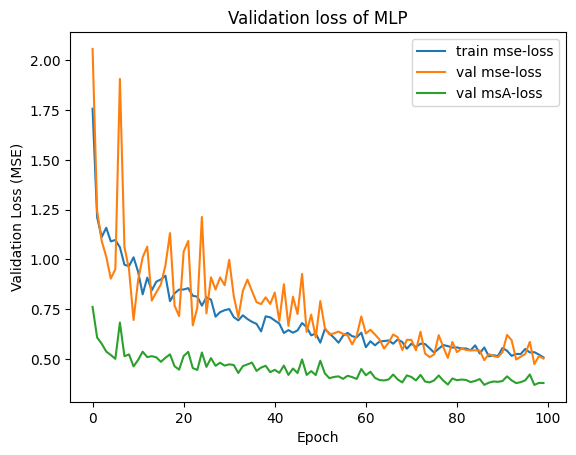

In [43]:
plt.figure()
plt.plot(hist_d.history["MSE"], label="train mse-loss")
plt.plot(hist_d.history["val_MSE"], label="val mse-loss")
plt.plot(hist_d.history["val_MAE"], label="val msA-loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.title("Validation loss of MLP")
plt.show()


In [44]:
blobPerFrame = np.load('version4ftrblobsPerFrameWITHCART.npy')
dataHeads = np.load('version4ftrtotalHeadsWITHCART.npy')
missedHeads = np.load('version4ftrmissedHeadsWITHCART.npy')

numFrames = (len(y_test_frame))

row_sums = (list(map(sum, y_test_frame)))

numpyMean = np.mean(dataHeads-missedHeads)
numpymean = numpyMean.astype(object)

testSet = model_d.evaluate(X_test_s,y_test_f)

print("MAE Test: ",float(testSet[2])*numpymean)
print("MSE Test: ",float(testSet[1])*numpymean)
print("Loss Test: ",float(testSet[0])*numpymean)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - MAE: 0.3789 - MSE: 0.5020 - loss: 0.6268
MAE Test:  24.43608918786049
MSE Test:  32.37646481394768
Loss Test:  40.43151417374611
